# Failure Analysis

Qualitative and quantitative analysis of VLM evaluation failures.
Covers failure distributions, parameter sensitivity, error patterns, and image-level failure galleries.

In [1]:

import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from analysis import load_results, wilson_ci

sns.set_theme(style="whitegrid")
%matplotlib inline

# --- Configuration ---
RESULTS_PATH = "../results/combined_both/results.jsonl"

# Load and normalize
results = load_results(RESULTS_PATH)
df = pd.DataFrame(results)
if "reasoning_mode" not in df.columns:
    df["reasoning_mode"] = False
else:
    df.loc[df["reasoning_mode"].isna(), "reasoning_mode"] = False
    df["reasoning_mode"] = df["reasoning_mode"].astype(bool)
df["mode"] = df["reasoning_mode"].map({True: "Reasoning", False: "No Reasoning"})

# Extract params into columns
params_df = pd.json_normalize(df["params"])
df = pd.concat([df.drop(columns=["params"]), params_df.add_prefix("p_")], axis=1)

# Derived columns
if "p_path" in df.columns:
    df["p_path_length"] = df["p_path"].apply(lambda x: len(x) if isinstance(x, list) else None)

failures = df[df["correct"] == False].copy()

print(f"Total samples: {len(df)}")
print(f"Total failures: {len(failures)} ({len(failures)/len(df):.1%})")
print(f"Modes: {df['mode'].value_counts().to_dict()}")


Total samples: 2452
Total failures: 776 (31.6%)
Modes: {'No Reasoning': 1226, 'Reasoning': 1226}


## 1. Failure Overview by Task

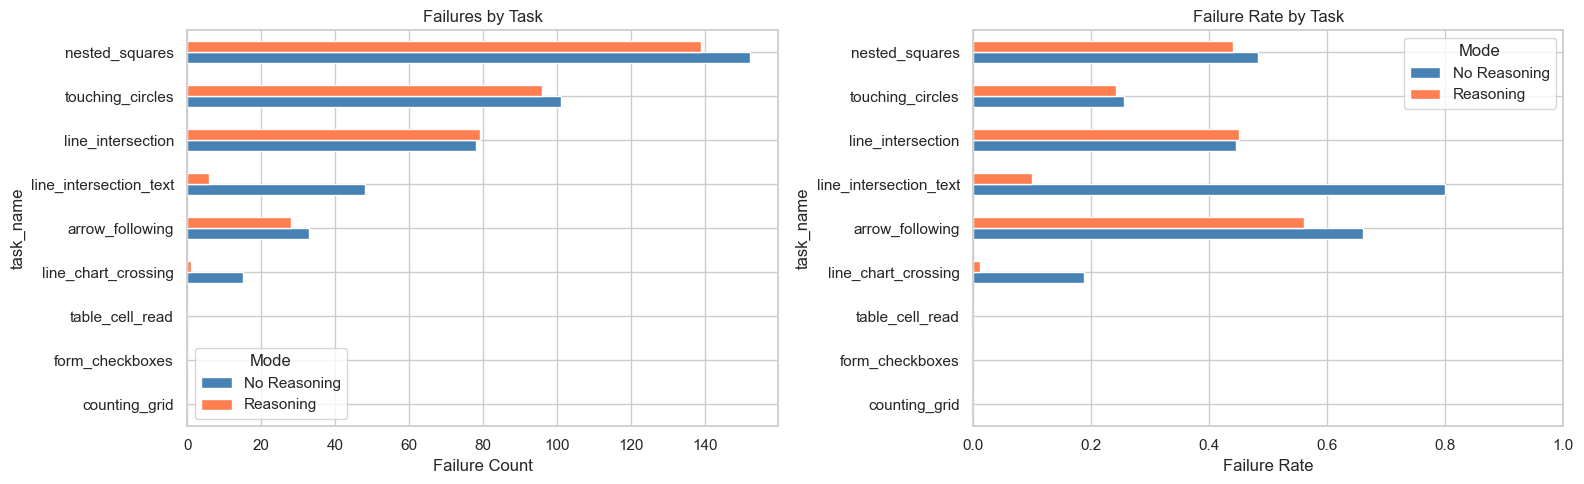


Task                       No-Reason Fail  Reasoning Fail    Delta
--------------------------------------------------------------------
counting_grid                       0.0%           0.0%   +0.0%
form_checkboxes                     0.0%           0.0%   +0.0%
table_cell_read                     0.0%           0.0%   +0.0%
line_chart_crossing                18.8%           1.2%  -17.5%
arrow_following                    66.0%          56.0%  -10.0%
line_intersection_text             80.0%          10.0%  -70.0%
line_intersection                  44.6%          45.1%   +0.6%
touching_circles                   25.5%          24.2%   -1.3%
nested_squares                     48.3%          44.1%   -4.1%


In [2]:
# Failure count and rate by task × mode
summary = df.groupby(["task_name", "mode"]).agg(
    n=("correct", "count"),
    n_fail=("correct", lambda x: (~x.astype(bool)).sum()),
    accuracy=("correct", "mean"),
).reset_index()
summary["failure_rate"] = 1 - summary["accuracy"]

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Failure count
pivot_count = summary.pivot(index="task_name", columns="mode", values="n_fail").fillna(0)
pivot_count = pivot_count.sort_values("No Reasoning", ascending=True)
pivot_count.plot.barh(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_xlabel("Failure Count")
axes[0].set_title("Failures by Task")
axes[0].legend(title="Mode")

# Failure rate
pivot_rate = summary.pivot(index="task_name", columns="mode", values="failure_rate").fillna(0)
pivot_rate = pivot_rate.loc[pivot_count.index]  # same order
pivot_rate.plot.barh(ax=axes[1], color=["steelblue", "coral"])
axes[1].set_xlabel("Failure Rate")
axes[1].set_title("Failure Rate by Task")
axes[1].set_xlim(0, 1)
axes[1].legend(title="Mode")

fig.tight_layout()
plt.show()

# Table
print(f"\n{'Task':<25} {'No-Reason Fail':>15} {'Reasoning Fail':>15} {'Delta':>8}")
print("-" * 68)
for task in pivot_rate.index:
    nr = pivot_rate.loc[task, "No Reasoning"]
    r = pivot_rate.loc[task, "Reasoning"]
    delta = r - nr
    print(f"{task:<25} {nr:>14.1%} {r:>14.1%} {delta:>+7.1%}")

## 2. Failure Rate by Task Parameter

Which parameter values cause the most failures?

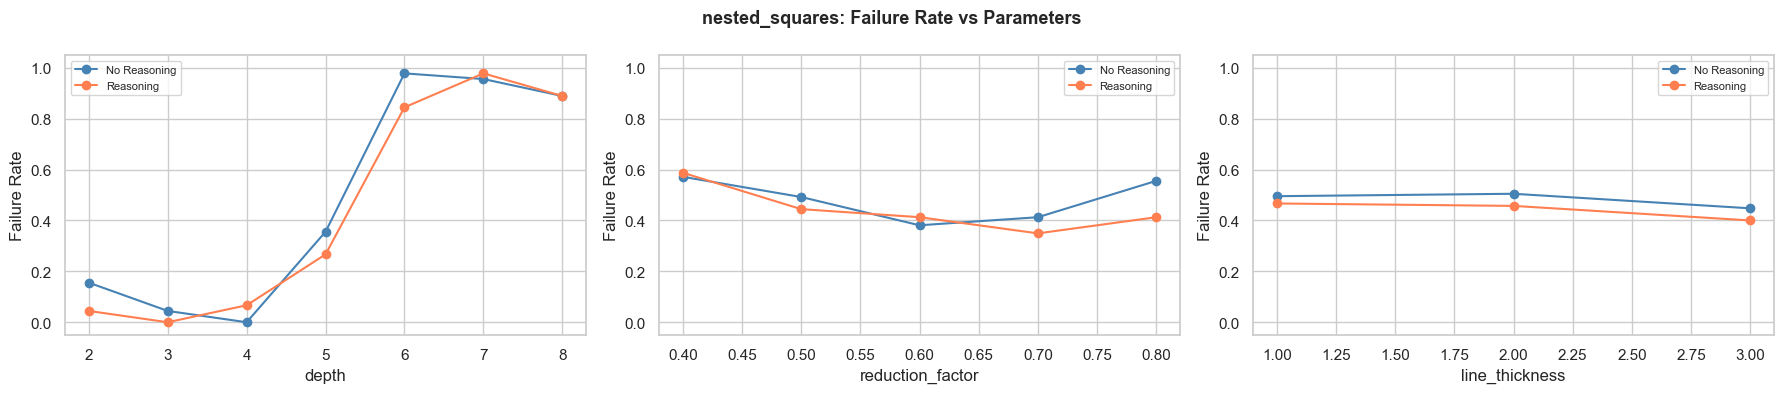

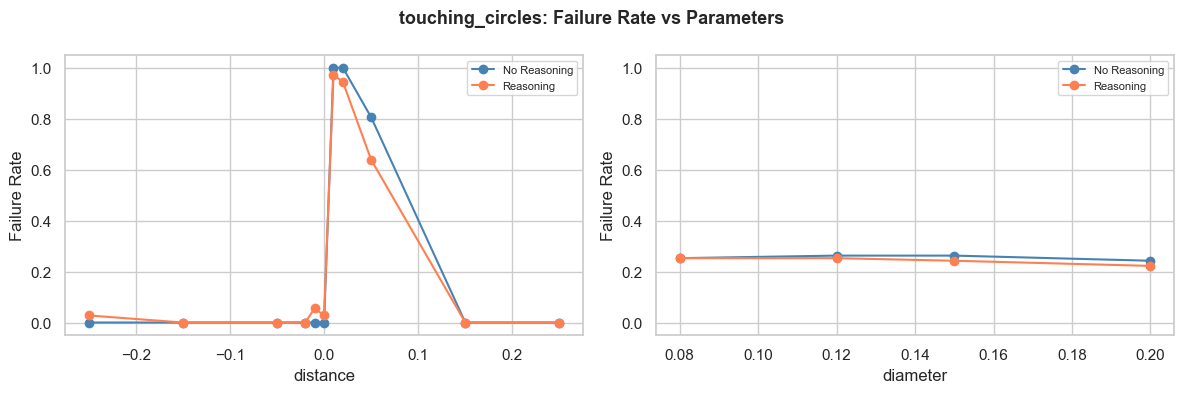

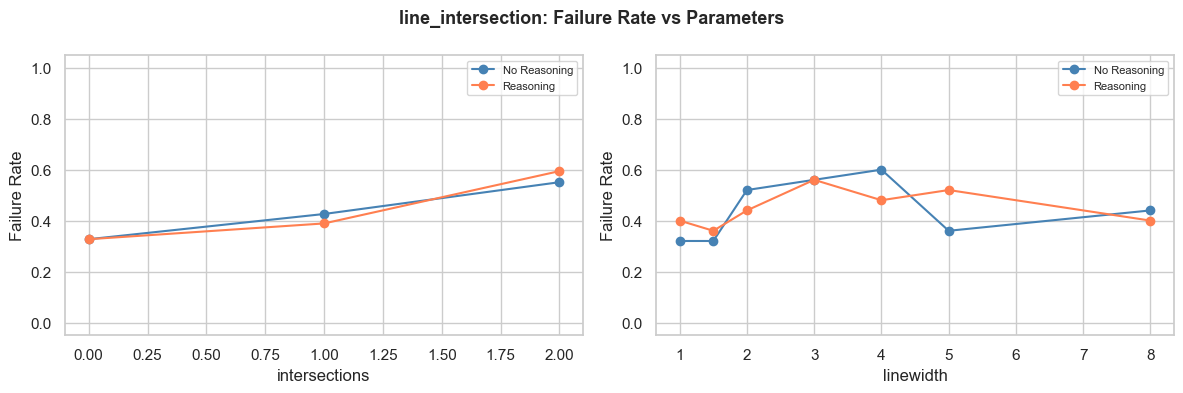

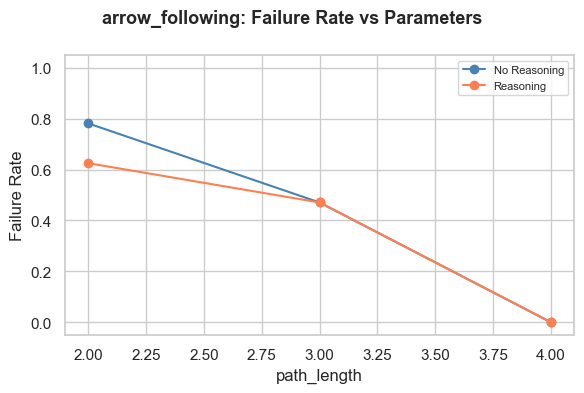

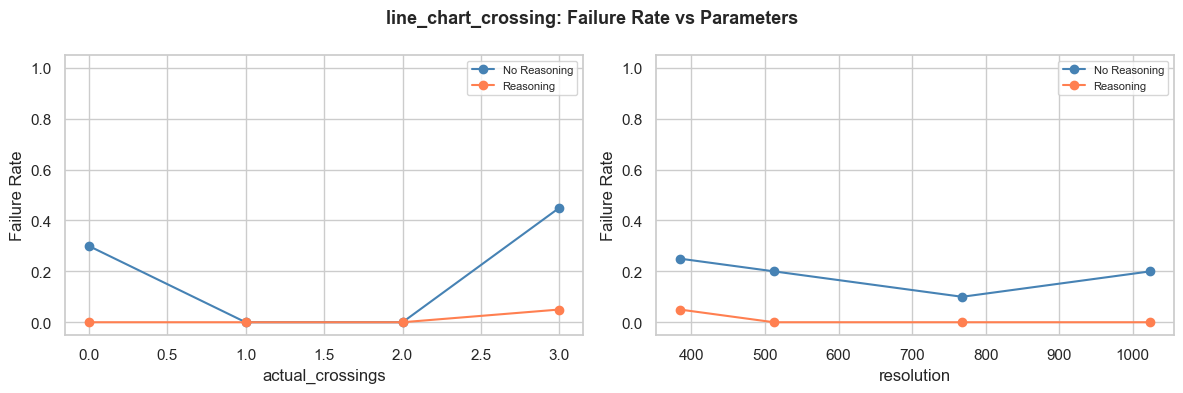

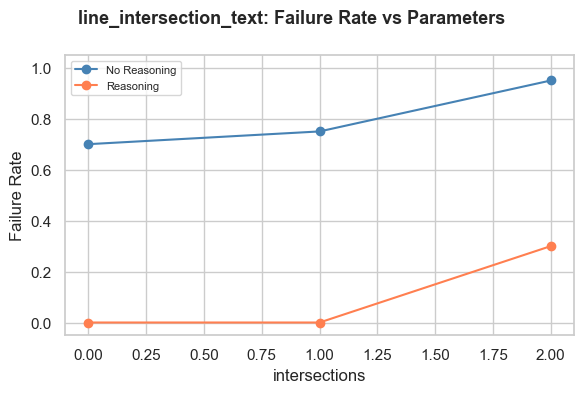

In [3]:

# Key parameters per task (only include params that actually vary)
TASK_PARAMS = {
    "nested_squares": ["p_depth", "p_reduction_factor", "p_line_thickness"],
    "touching_circles": ["p_distance", "p_diameter"],
    "line_intersection": ["p_intersections", "p_linewidth"],
    "arrow_following": ["p_path_length"],
    "line_chart_crossing": ["p_actual_crossings", "p_resolution"],
    "line_intersection_text": ["p_intersections"],
}

for task_name, param_cols in TASK_PARAMS.items():
    task_df = df[df["task_name"] == task_name]
    if len(task_df) == 0:
        continue
    
    valid_cols = [c for c in param_cols if c in task_df.columns and task_df[c].nunique() > 1]
    if not valid_cols:
        continue
    
    n_cols = len(valid_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    
    for ax, col in zip(axes, valid_cols):
        # Failure rate by param value, split by mode
        grouped = task_df.groupby([col, "mode"])["correct"].agg(["mean", "count"]).reset_index()
        grouped["failure_rate"] = 1 - grouped["mean"]
        
        for mode, color in [("No Reasoning", "steelblue"), ("Reasoning", "coral")]:
            mode_data = grouped[grouped["mode"] == mode].sort_values(col)
            if len(mode_data) > 0:
                ax.plot(mode_data[col], mode_data["failure_rate"], "o-", color=color,
                        label=mode, markersize=6)
        
        ax.set_xlabel(col.replace("p_", ""))
        ax.set_ylabel("Failure Rate")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
    
    fig.suptitle(f"{task_name}: Failure Rate vs Parameters", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


## 3. Error Distribution (Counting Tasks)

Signed error histograms showing overcounting (+) vs undercounting (-) bias.

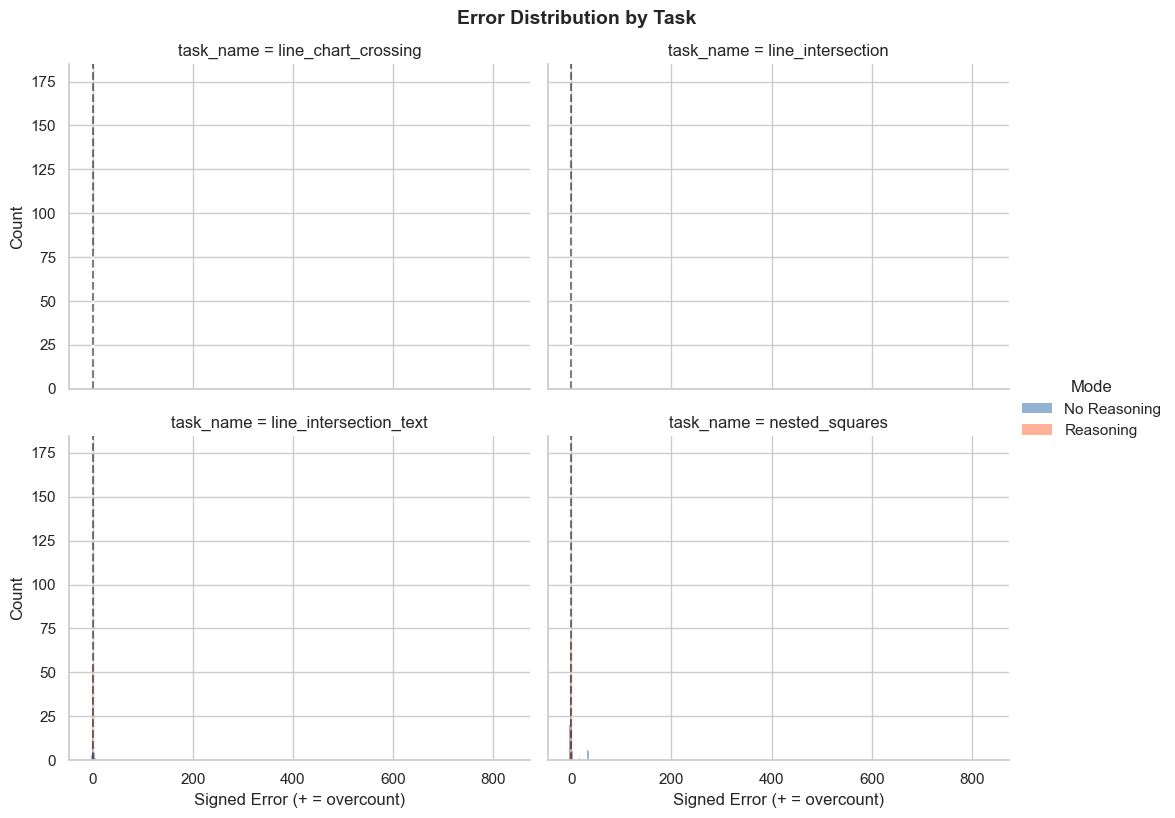


Task                      Mode             Mean Err   Over%   Under%   Exact%
---------------------------------------------------------------------------
nested_squares            No Reasoning       +1.48  17.1%   31.1%   51.7%
nested_squares            Reasoning          -0.62   1.9%   42.2%   55.9%
line_intersection         No Reasoning       +0.14  25.7%   18.9%   55.4%
line_intersection         Reasoning          +0.06  24.0%   21.1%   54.9%
line_intersection_text    No Reasoning      +15.45  56.7%   23.3%   20.0%
line_intersection_text    Reasoning          -0.10   0.0%   10.0%   90.0%
line_chart_crossing       No Reasoning       +0.80  13.8%    5.0%   81.2%
line_chart_crossing       Reasoning          +0.03   1.2%    0.0%   98.8%


In [4]:
counting_tasks = ["nested_squares", "line_intersection", "line_intersection_text", "line_chart_crossing"]
counting_df = df[df["task_name"].isin(counting_tasks) & df["error"].notna()].copy()

if len(counting_df) > 0:
    g = sns.FacetGrid(counting_df, col="task_name", hue="mode", col_wrap=2,
                      height=4, aspect=1.3, palette={"No Reasoning": "steelblue", "Reasoning": "coral"})
    g.map(sns.histplot, "error", kde=False, alpha=0.6, stat="count", discrete=True)
    g.add_legend(title="Mode")
    for ax in g.axes.flat:
        ax.axvline(0, color="black", linestyle="--", alpha=0.5)
        ax.set_xlabel("Signed Error (+ = overcount)")
    g.fig.suptitle("Error Distribution by Task", y=1.02, fontsize=14, fontweight="bold")
    plt.show()
    
    # Summary stats
    print(f"\n{'Task':<25} {'Mode':<15} {'Mean Err':>9} {'Over%':>7} {'Under%':>8} {'Exact%':>8}")
    print("-" * 75)
    for task in counting_tasks:
        for mode in ["No Reasoning", "Reasoning"]:
            t = counting_df[(counting_df["task_name"] == task) & (counting_df["mode"] == mode)]
            if len(t) == 0:
                continue
            errs = t["error"]
            print(f"{task:<25} {mode:<15} {errs.mean():>+8.2f} {(errs>0).mean():>6.1%} "
                  f"{(errs<0).mean():>7.1%} {(errs==0).mean():>7.1%}")

## 4. Confusion Matrices

Side-by-side confusion matrices for counting tasks (No Reasoning vs Reasoning).

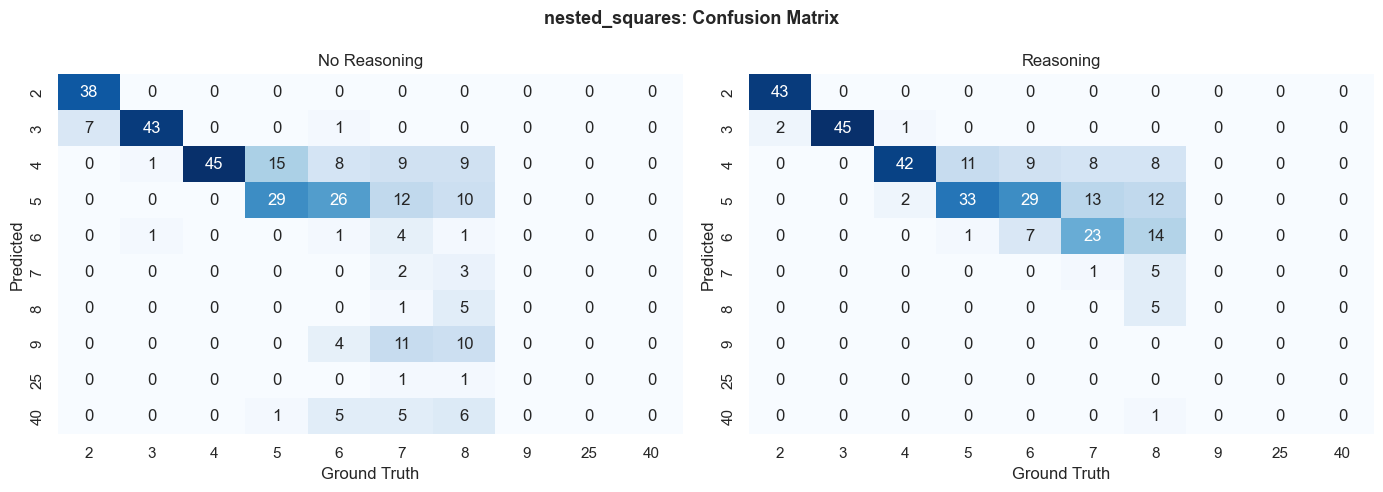

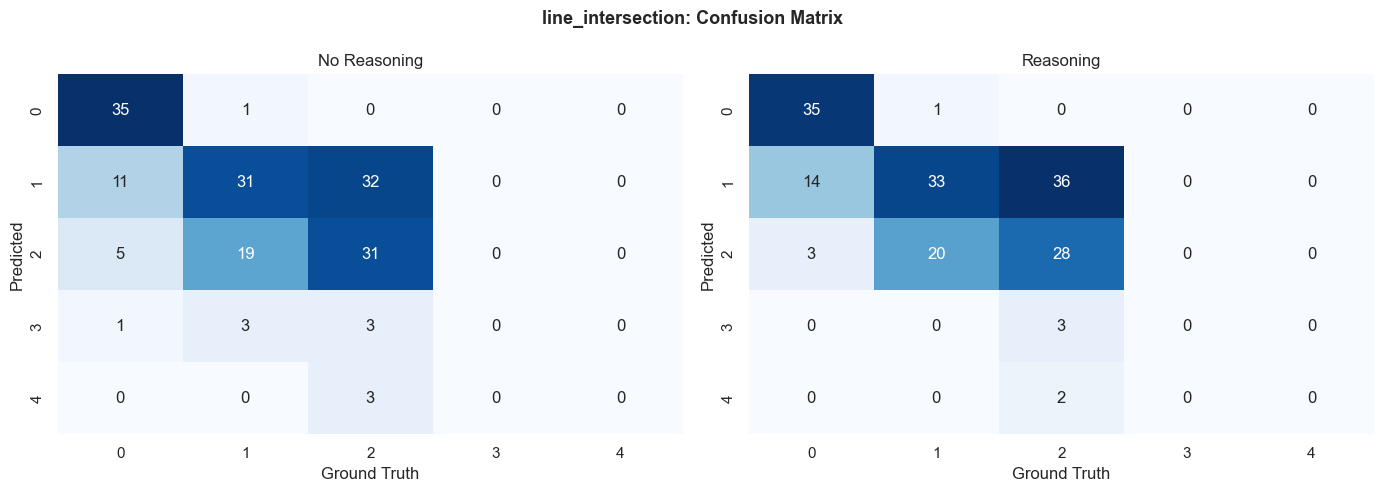

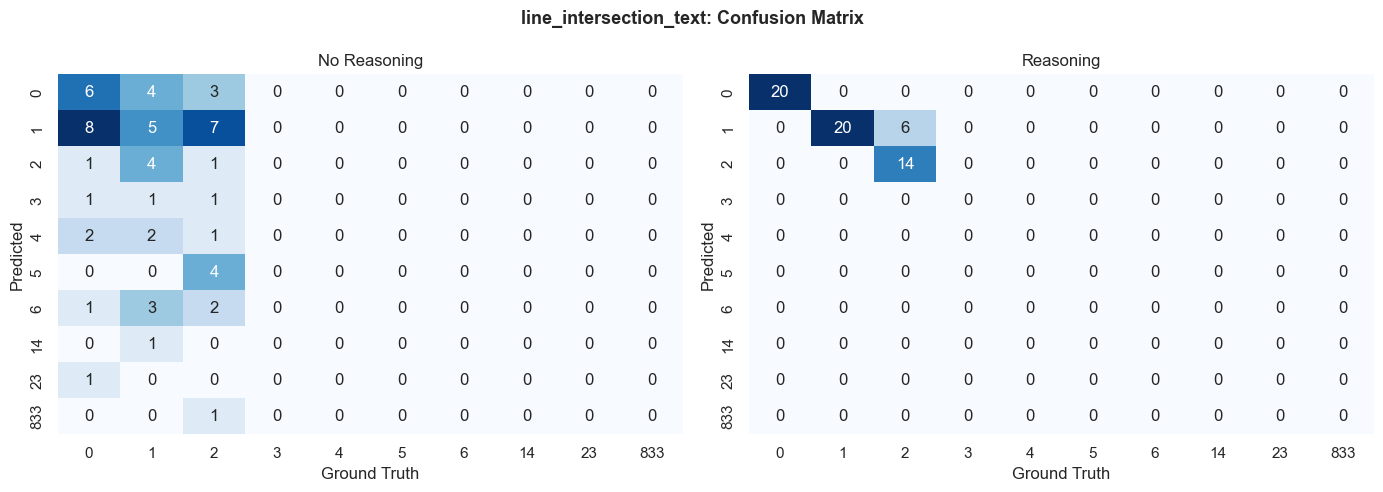

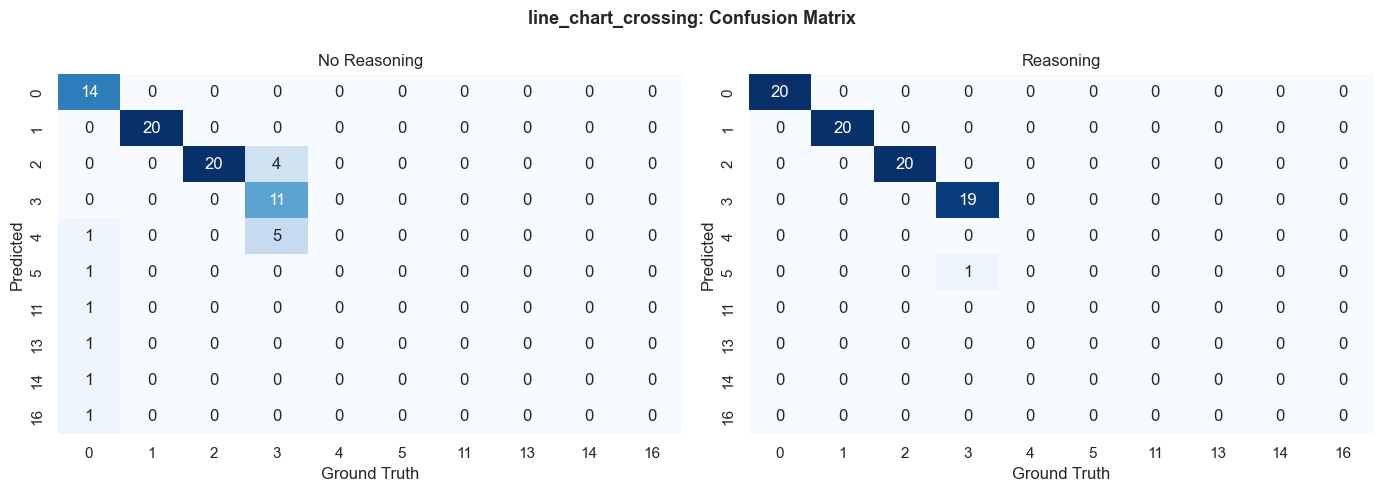

In [5]:
for task in counting_tasks:
    task_df = df[(df["task_name"] == task) & df["parsed_answer"].notna()].copy()
    if len(task_df) < 10:
        continue
    
    try:
        task_df["gt_int"] = task_df["ground_truth"].astype(int)
        task_df["pred_int"] = task_df["parsed_answer"].astype(int)
    except (ValueError, TypeError):
        continue
    
    all_vals = sorted(set(task_df["gt_int"]) | set(task_df["pred_int"]))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, mode in zip(axes, ["No Reasoning", "Reasoning"]):
        mode_df = task_df[task_df["mode"] == mode]
        if len(mode_df) < 5:
            ax.set_visible(False)
            continue
        confusion = pd.crosstab(mode_df["pred_int"], mode_df["gt_int"], dropna=False)
        confusion = confusion.reindex(index=all_vals, columns=all_vals, fill_value=0)
        sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
        ax.set_xlabel("Ground Truth")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{mode}")
    
    fig.suptitle(f"{task}: Confusion Matrix", fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

## 5. Failure Gallery

View individual failure cases with images, model responses, and ground truth.

**Change `TASK`, `MODE`, and `N` below to explore different failure categories.**

In [6]:
def show_failures(dataframe, title="Failures", n=8, show_thinking=True):
    """Display a grid of failure cases with images and annotations."""
    samples = dataframe.head(n)
    if len(samples) == 0:
        print("No failures to display.")
        return
    
    n_actual = len(samples)
    n_cols = min(4, n_actual)
    n_rows = (n_actual + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        
        # Load and show image
        img_path = row["image_path"]
        if Path(img_path).exists():
            img = mpimg.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        
        # Build caption
        mode_tag = "[R]" if row.get("reasoning_mode", False) else "[NR]"
        gt = row["ground_truth"]
        pred = row.get("parsed_answer", "??")
        response = str(row.get("raw_response", ""))[:120]
        
        caption = f"{mode_tag} GT: {gt}  Pred: {pred}\n{response}"
        
        if show_thinking and row.get("thinking_text"):
            thinking = str(row["thinking_text"])[:150]
            caption += f"\n---\nThinking: {thinking}..."
        
        ax.set_title(f"{row['task_name']} ({row['sample_id']})", fontsize=9, fontweight="bold")
        ax.text(0.5, -0.02, caption, transform=ax.transAxes, fontsize=7,
                va="top", ha="center", wrap=True,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))
    
    # Hide unused axes
    for idx in range(n_actual, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)
    
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

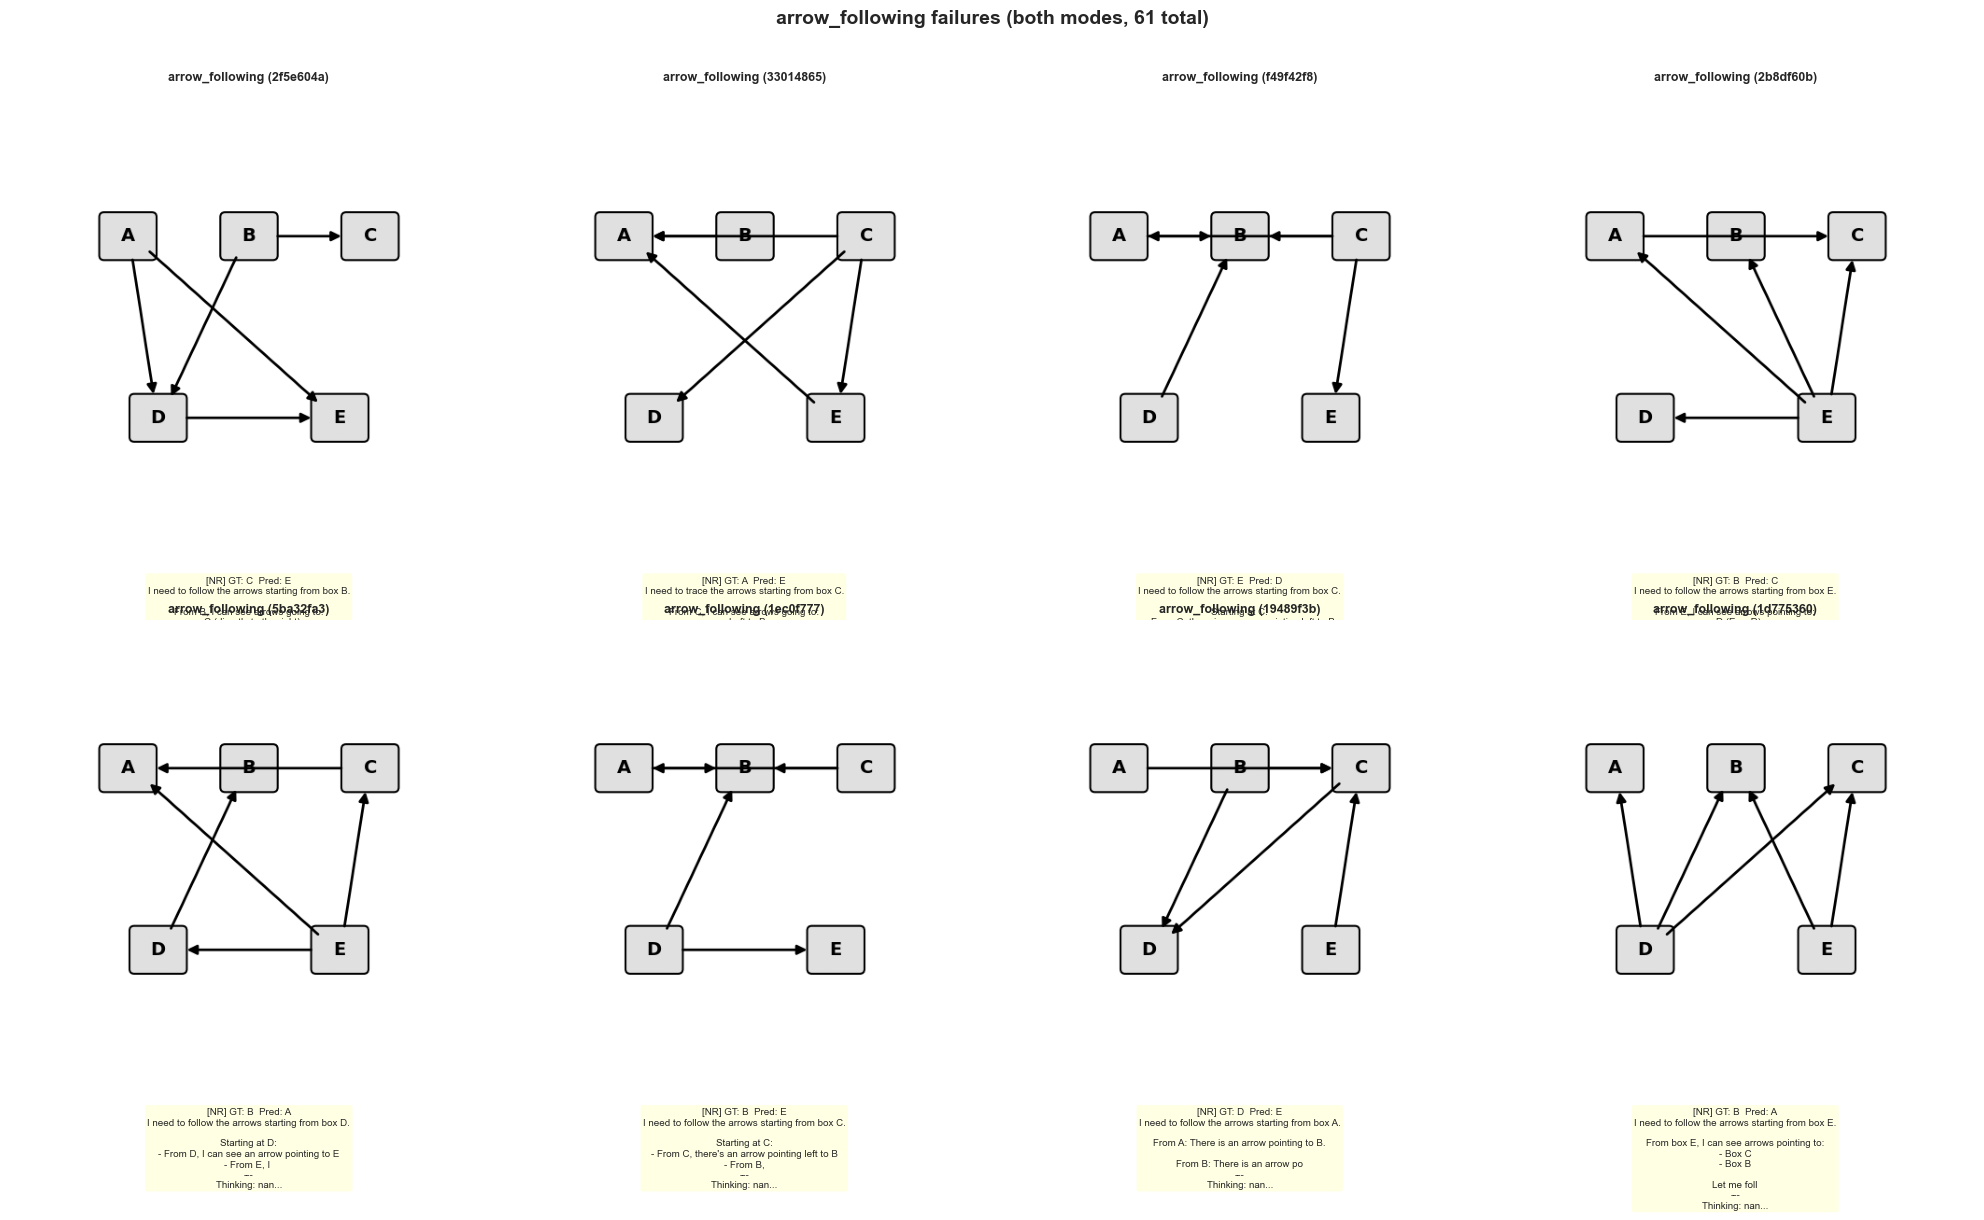

In [7]:
# === CONFIGURE THESE ===
TASK = "arrow_following"    # Change to any task name
MODE = None                 # None = both, "Reasoning", or "No Reasoning"
N = 8                       # Number of failures to show
# =======================

gallery_df = failures[failures["task_name"] == TASK].copy()
if MODE is not None:
    gallery_df = gallery_df[gallery_df["mode"] == MODE]

mode_label = MODE or "both modes"
show_failures(gallery_df, title=f"{TASK} failures ({mode_label}, {len(gallery_df)} total)", n=N)

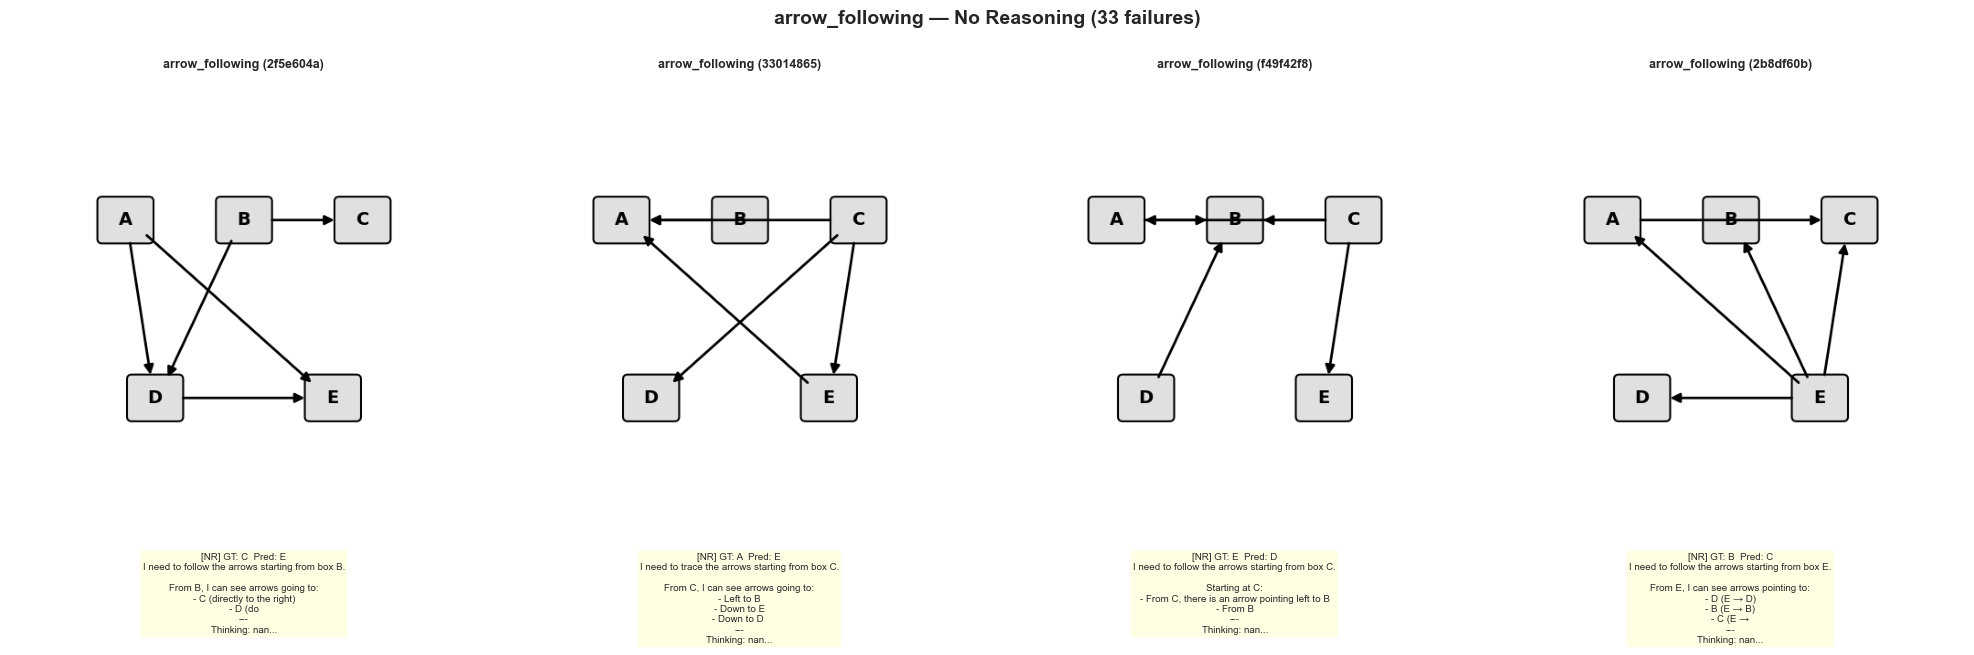

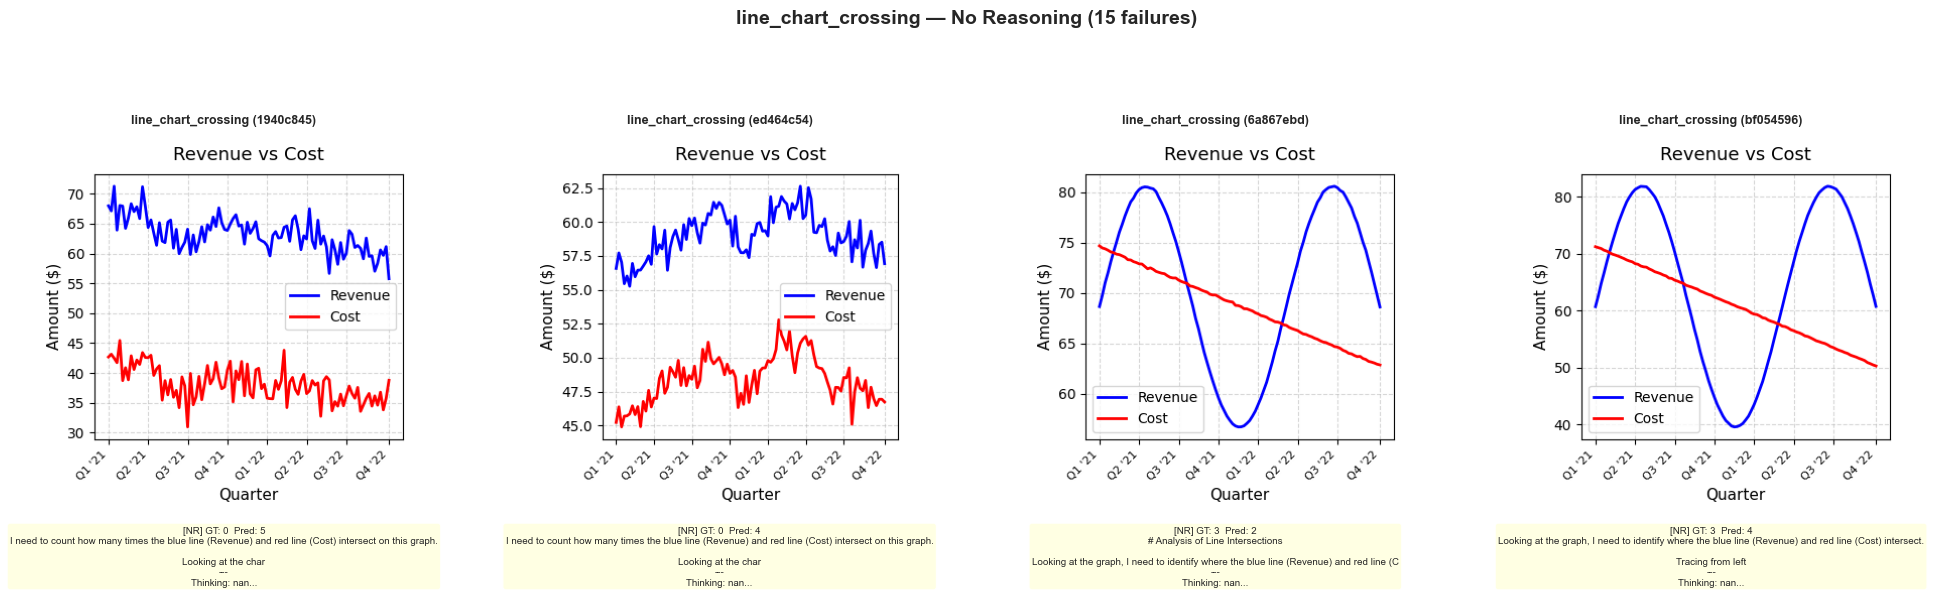

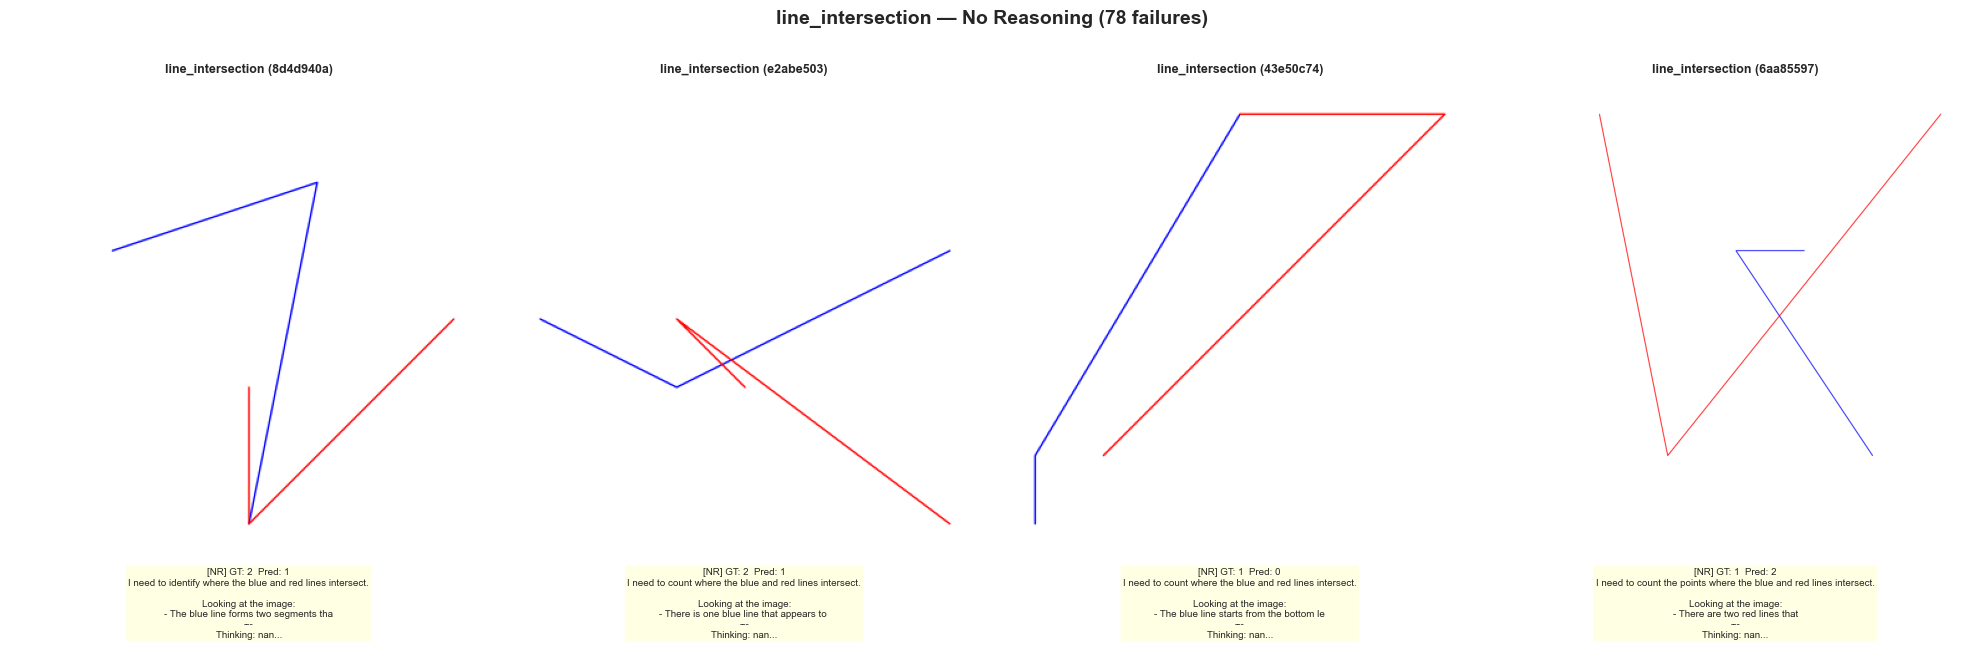

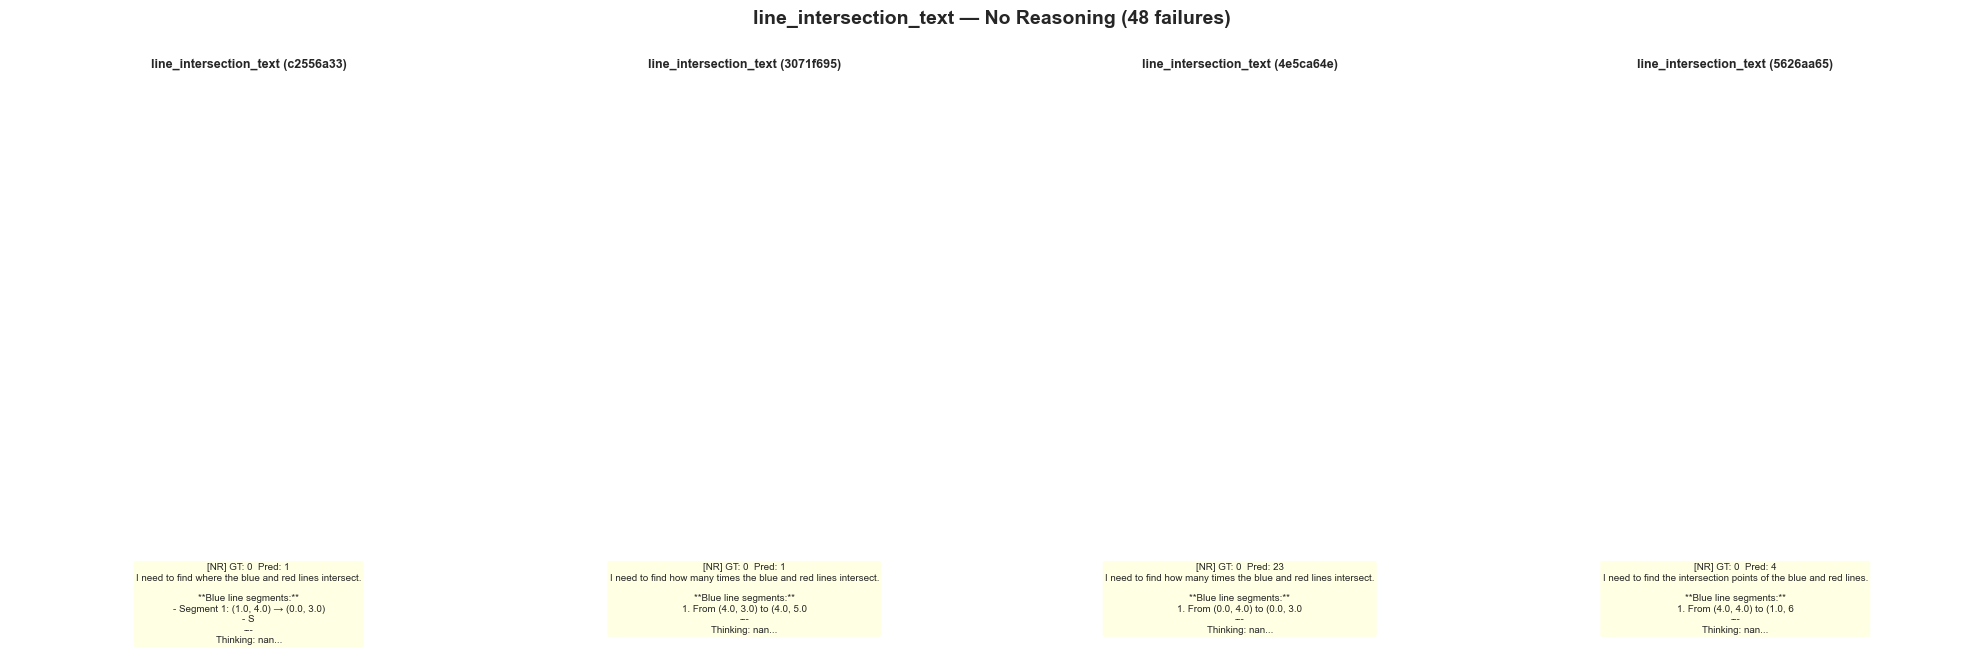

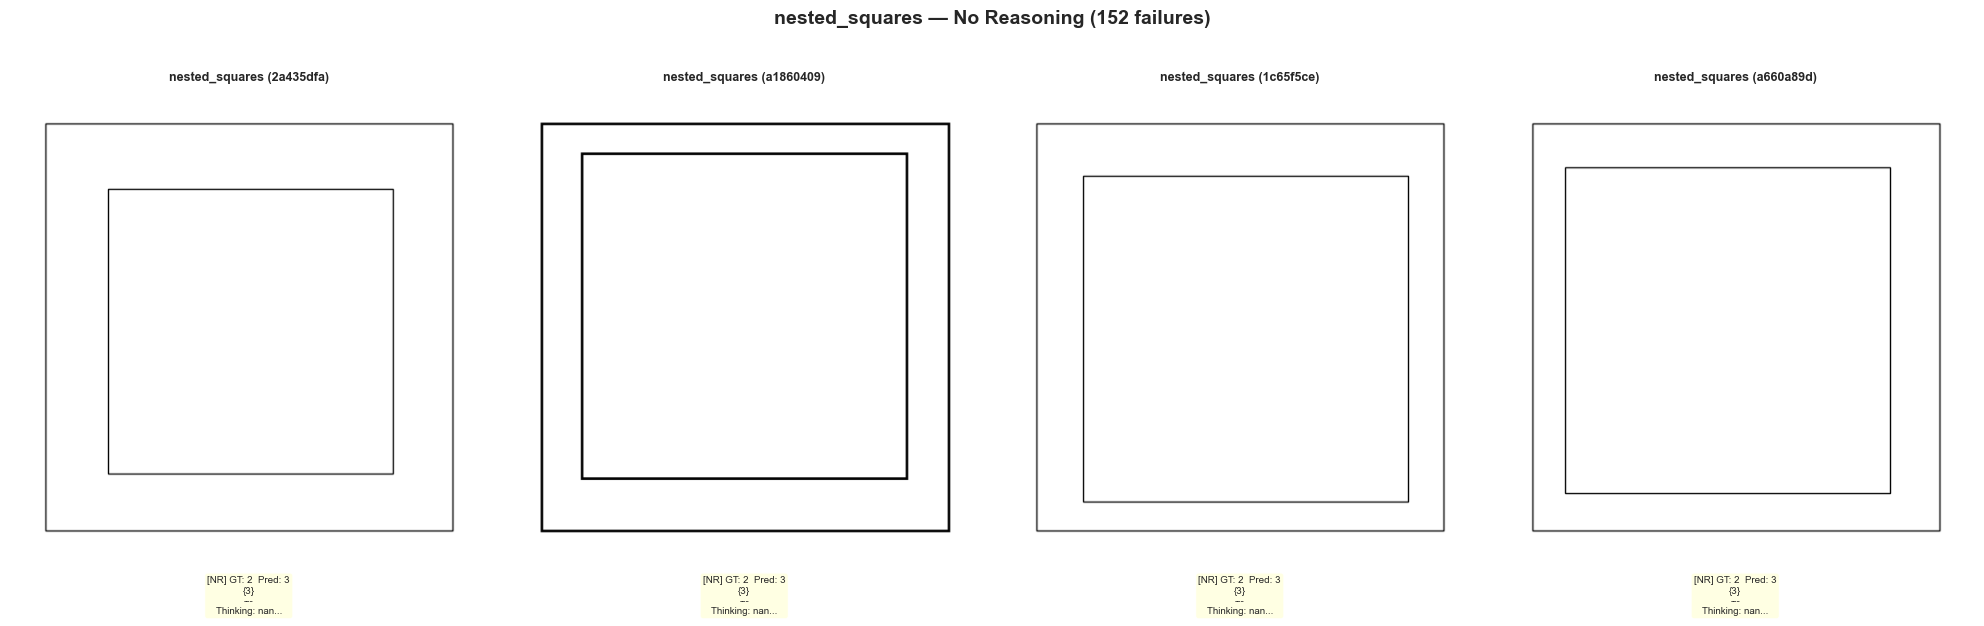

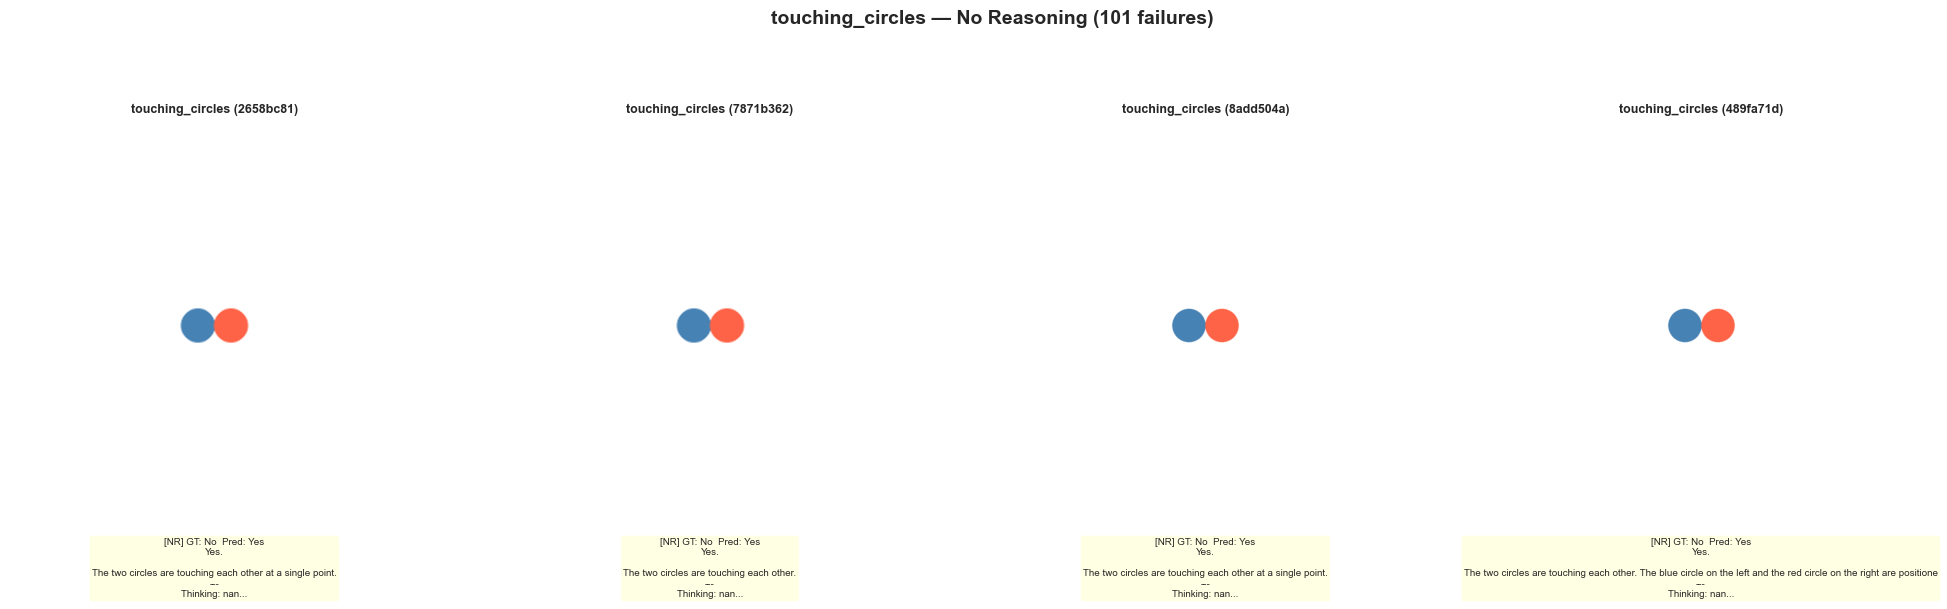

In [8]:
# Show top 4 failures per task (no-reasoning mode)
for task in sorted(failures["task_name"].unique()):
    task_fails = failures[(failures["task_name"] == task) & (failures["mode"] == "No Reasoning")]
    if len(task_fails) == 0:
        continue
    show_failures(task_fails, title=f"{task} — No Reasoning ({len(task_fails)} failures)", n=4)

## 6. Hardest Samples (Fail in Both Modes)

Samples that are wrong both with and without reasoning — true blind spots where
extended thinking doesn't help.

In [ ]:
# Find sample_ids that fail in both modes
fail_nr = set(failures[failures["mode"] == "No Reasoning"]["sample_id"])
fail_r = set(failures[failures["mode"] == "Reasoning"]["sample_id"])
fail_both = fail_nr & fail_r
fail_only_nr = fail_nr - fail_r  # fixed by reasoning
fail_only_r = fail_r - fail_nr   # broken by reasoning

print(f"Fail in both modes:       {len(fail_both)}")
print(f"Fail only w/o reasoning:  {len(fail_only_nr)} (fixed by reasoning)")
print(f"Fail only w/ reasoning:   {len(fail_only_r)} (regression from reasoning)")

# Distribution by task
both_df = failures[failures["sample_id"].isin(fail_both) & (failures["mode"] == "No Reasoning")]
print(f"\nHardest samples by task:")
print(both_df["task_name"].value_counts().to_string())

# Show gallery
show_failures(both_df, title=f"Hardest Samples — Fail in Both Modes ({len(both_df)} total)", n=8)

## 7. Reasoning Regressions

Samples correct WITHOUT reasoning but wrong WITH reasoning.
Shows cases where extended thinking actively hurts.

In [ ]:
# Get regression cases
regression_df = failures[failures["sample_id"].isin(fail_only_r) & (failures["mode"] == "Reasoning")].copy()

print(f"Reasoning regressions by task:")
print(regression_df["task_name"].value_counts().to_string())

show_failures(regression_df, title=f"Reasoning Regressions ({len(regression_df)} total)", n=8)

In [ ]:
# Side-by-side: show both the correct (NR) and wrong (R) response for regression cases
for sid in list(fail_only_r)[:5]:
    nr_row = df[(df["sample_id"] == sid) & (df["mode"] == "No Reasoning")].iloc[0]
    r_row = df[(df["sample_id"] == sid) & (df["mode"] == "Reasoning")].iloc[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    img_path = nr_row["image_path"]
    if Path(img_path).exists():
        img = mpimg.imread(img_path)
        for ax in axes:
            ax.imshow(img)
            ax.axis("off")
    
    # No reasoning (correct)
    nr_resp = str(nr_row["raw_response"])[:200]
    axes[0].set_title(f"No Reasoning — CORRECT\nGT: {nr_row['ground_truth']}  Pred: {nr_row['parsed_answer']}",
                      fontsize=10, color="green")
    axes[0].text(0.5, -0.02, nr_resp, transform=axes[0].transAxes, fontsize=7,
                 va="top", ha="center", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8))
    
    # Reasoning (wrong)
    r_resp = str(r_row["raw_response"])[:200]
    thinking = str(r_row.get("thinking_text", ""))[:150]
    axes[1].set_title(f"Reasoning — WRONG\nGT: {r_row['ground_truth']}  Pred: {r_row['parsed_answer']}",
                      fontsize=10, color="red")
    caption = f"{r_resp}\n---Thinking: {thinking}..."
    axes[1].text(0.5, -0.02, caption, transform=axes[1].transAxes, fontsize=7,
                 va="top", ha="center", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    
    fig.suptitle(f"{nr_row['task_name']} — {sid}", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

## 8. Fixed by Reasoning

Samples wrong WITHOUT reasoning but correct WITH reasoning.
Shows where extended thinking successfully recovers.

In [ ]:
fixed_df = failures[failures["sample_id"].isin(fail_only_nr) & (failures["mode"] == "No Reasoning")].copy()

print(f"Fixed by reasoning by task:")
print(fixed_df["task_name"].value_counts().to_string())

# Show the reasoning response that got it right
for sid in list(fail_only_nr)[:5]:
    nr_row = df[(df["sample_id"] == sid) & (df["mode"] == "No Reasoning")].iloc[0]
    r_row = df[(df["sample_id"] == sid) & (df["mode"] == "Reasoning")].iloc[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    img_path = nr_row["image_path"]
    if Path(img_path).exists():
        img = mpimg.imread(img_path)
        for ax in axes:
            ax.imshow(img)
            ax.axis("off")
    
    # No reasoning (wrong)
    nr_resp = str(nr_row["raw_response"])[:200]
    axes[0].set_title(f"No Reasoning — WRONG\nGT: {nr_row['ground_truth']}  Pred: {nr_row['parsed_answer']}",
                      fontsize=10, color="red")
    axes[0].text(0.5, -0.02, nr_resp, transform=axes[0].transAxes, fontsize=7,
                 va="top", ha="center", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    
    # Reasoning (correct)
    r_resp = str(r_row["raw_response"])[:200]
    thinking = str(r_row.get("thinking_text", ""))[:150]
    axes[1].set_title(f"Reasoning — CORRECT\nGT: {r_row['ground_truth']}  Pred: {r_row['parsed_answer']}",
                      fontsize=10, color="green")
    caption = f"{r_resp}\n---Thinking: {thinking}..."
    axes[1].text(0.5, -0.02, caption, transform=axes[1].transAxes, fontsize=7,
                 va="top", ha="center", wrap=True,
                 bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8))
    
    fig.suptitle(f"{nr_row['task_name']} — {sid}", fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()